In [1]:
import sys
sys.path.append('../GC_stream')

from tqdm import tqdm
import numpy as np
import matplotlib as mpl
from matplotlib import colormaps
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patheffects as PathEffects
from matplotlib.colors import LinearSegmentedColormap
from scipy.interpolate import interp1d, UnivariateSpline
from scipy.stats import binned_statistic, binned_statistic_2d, gaussian_kde
from scipy.signal import find_peaks
from scipy.optimize import minimize
from scipy import linalg
from scipy.interpolate import RegularGridInterpolator
from astropy.io import fits
import astropy.units as u
import astropy.coordinates as coord
import pandas as pd
from ezpadova import parsec

import gala.coordinates as galac
import gala.dynamics as gd
import gala.potential as gp
from gala.units import galactic
from gala.dynamics import mockstream as ms
_ = coord.galactocentric_frame_defaults.set('v4.0')

import agama
agama.setUnits(length=1, velocity=1, mass=1)

from cmcrameri.cm import batlow

import stream_dataset as sd
import GC
import agama_stream as ags

<frozen importlib._bootstrap>:219: RuntimeWarning: scipy._lib.messagestream.MessageStream size changed, may indicate binary incompatibility. Expected 56 from C header, got 64 from PyObject
        Use @ instead. [gala.coordinates.sgr]
        Use @ instead. [gala.coordinates.orphan]
        Use @ instead. [gala.coordinates.magellanic_stream]


In [2]:
plt.rcParams['font.sans-serif'] = ['helvetica', 'DejaVu Sans',
                               'Lucida Grande', 'Verdana']

In [3]:
# force reimport

import importlib
importlib.reload(sd)
importlib.reload(GC)
importlib.reload(ags)

<module 'agama_stream' from '../GC_stream/agama_stream.py'>

In [4]:
def get_peri_apo(x,y,z):
    r2 = x**2 + y**2 + z**2
    median = np.median(r2)
    peaks_apo, _ = find_peaks(r2, height=median)
    peaks_peri, _ = find_peaks(-r2, height=-median)

    return peaks_apo, peaks_peri

In [5]:
def get_h(arr,n):
    arrlen = len(arr)
    h = np.full(arrlen, fill_value=np.nan)
    idx = np.argsort(arr)
    for i in range(arrlen):
        neighbor = arr[idx[np.max([i-n,0]):np.min([i+n+1,arrlen])]]
        h[idx[i]] = np.sort(np.abs(neighbor-arr[idx[i]]))[n]

    return h

**load GC data**

In [6]:
# load GC info as pandas dataframe
gc_list = GC.load_GC()

# use Koposov+17 for Pal 5
gc_list.at['Pal_5', 'RA'] = 229
gc_list.at['Pal_5', 'DEC'] = -0.111
gc_list.at['Pal_5', 'Rsun'] = 23.6 # hilker: 21.94, Koposov: 23.6
gc_list.at['Pal_5', 'R_Sun'] = 23.6 # hilker: 21.94, Koposov: 23.6
gc_list.at['Pal_5', 'mu_alpha'] = -2.23
gc_list.at['Pal_5', 'mu_delta'] = -2.22
gc_list.at['Pal_5', '<RV>'] = -58.51 # hilker: 58.51, Koposov: 57.4

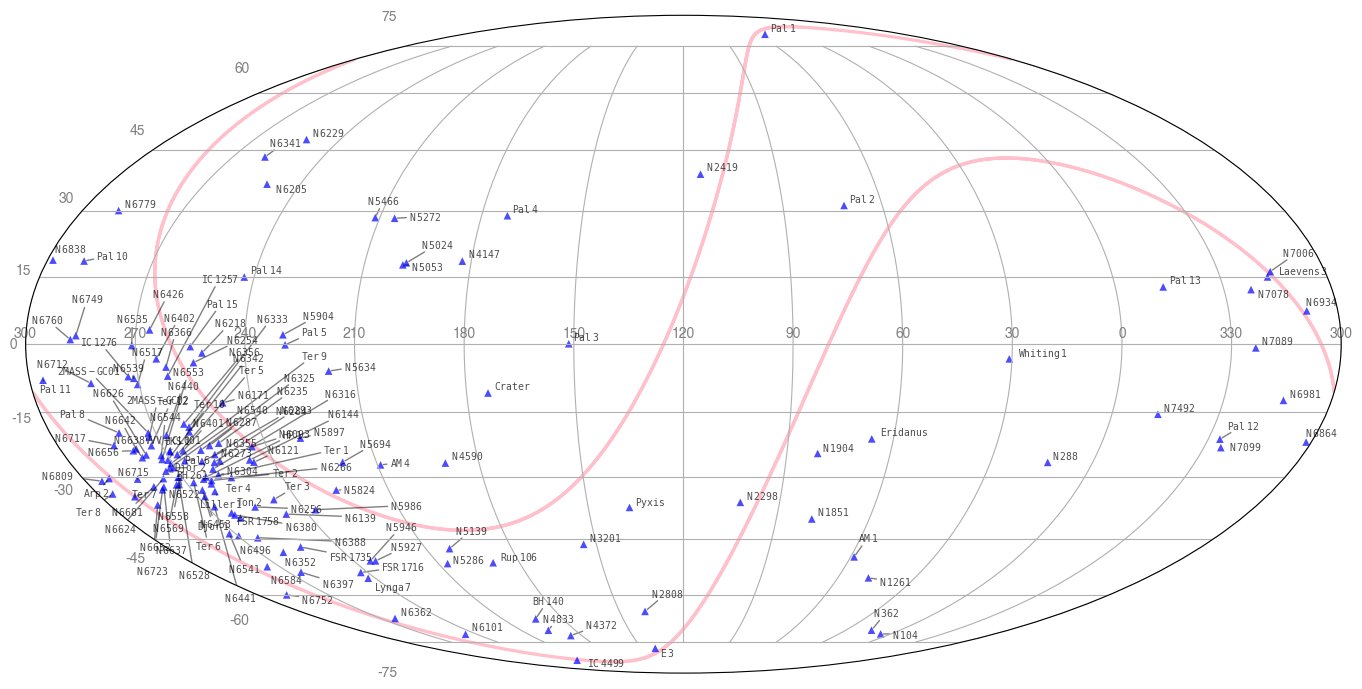

In [7]:
from adjustText import adjust_text

def galactic_to_equatorial(l_deg, b_deg):
    """
    Convert galactic coordinates (l, b) in degrees to equatorial
    coordinates (RA, Dec) in radians (J2000).
    """
    # Convert to radians
    l = np.deg2rad(l_deg)
    b = np.deg2rad(b_deg)
    # IAU 1958 / J2000 parameters
    alpha_ngp = np.deg2rad(192.85948)  # RA of North Galactic Pole
    delta_ngp = np.deg2rad(27.12825)   # Dec of North Galactic Pole
    l_omega   = np.deg2rad(32.93192)   # Galactic longitude of ascending node

    sin_dec = (
        np.sin(b) * np.sin(delta_ngp) +
        np.cos(b) * np.cos(delta_ngp) * np.sin(l - l_omega)
    )
    dec = np.arcsin(sin_dec)

    y = np.cos(b) * np.cos(l - l_omega)
    x = (
        np.sin(b) * np.cos(delta_ngp) -
        np.cos(b) * np.sin(delta_ngp) * np.sin(l - l_omega)
    )
    ra = np.arctan2(y, x) + alpha_ngp
    ra = np.mod(ra, 2 * np.pi)
    return ra, dec

# ------------------------------------------------------------------
ra_list, dec_list, name_list = [], [], []
for cluster in gc_list.index:
    ra_list.append(gc_list.loc[cluster].RA)
    dec_list.append(gc_list.loc[cluster].DEC)
    name_list.append(cluster)

ra_gc = np.array(ra_list)
dec_gc = np.array(dec_list)

# ------------------------------------------------------------------
# Shift RA so that 300° is at center
ra_shift = np.remainder(120 - ra_gc + 360, 360)
ra_rad = np.deg2rad(ra_shift)
ra_rad = np.where(ra_rad > np.pi, ra_rad - 2 * np.pi, ra_rad)
dec_rad = np.deg2rad(dec_gc)

# ------------------------------------------------------------------
# Plotting
fig = plt.figure(figsize=(14, 7))
ax = fig.add_subplot(111, projection='mollweide')

# Scatter globular cluster positions
texts = []
for ra_pt, dec_pt, name in zip(ra_rad, dec_rad, name_list):
    if not np.isnan(ra_pt):
        ax.scatter(ra_pt, dec_pt, s=30, alpha=0.7, fc='b', ec='none', marker='^')
        # ax.annotate(r'$\bf %s$'%name.replace('NGC_', 'N').replace('_', ''), (ra_pt, dec_pt), fontsize=6)
        # ax.text(ra_pt, dec_pt, r'$\bf %s$'%name.replace('NGC_', 'N').replace('_', ''), fontsize=6, ha='right', va='bottom')
        texts.append(plt.text(ra_pt, dec_pt, r'$\tt %s$'%name.replace('NGC', 'N').replace('_', '\,'), fontsize=7, color='k', alpha=0.7))

# Overlay b = +20° and -20°
l_vals = np.linspace(0, 360, 2000)
for b_val, style in zip([20, -20], ['-', '--']):
    ra_line, dec_line = galactic_to_equatorial(l_vals, b_val)
    ra_line_deg = np.rad2deg(ra_line)
    dec_line_deg = np.rad2deg(dec_line)

    # c = coord.SkyCoord(ra=ra_line_deg*u.deg, dec=dec_line_deg*u.deg)
    # ra_line_rad = c.ra.wrap_at(300*u.deg).radian
    # dec_line_rad = c.dec.radian

    # apply same RA shift & wrapping
    ra_line_shift = np.remainder(120-ra_line_deg, 360)
    ra_line_rad = np.deg2rad(ra_line_shift)
    ra_line_rad = np.where(ra_line_rad > np.pi, ra_line_rad - 2 * np.pi, ra_line_rad)
    dec_line_rad = np.deg2rad(dec_line_deg)

    ax.scatter(ra_line_rad, dec_line_rad, fc='pink', ec='None', s=6, zorder=0)

ax.grid(True)
# ax.set_xticklabels([])
ax.set_xticks(np.array([-180,-150,-120,-90,-60,-30,0,30,60,90,120,150,180])*np.pi/180,
    [r'300',r'270',r'240',r'210',r'180',r'150',r'120',r'90',r'60',r'30',r'0',r'330',r'300'], fontsize=10, color='gray', zorder=0)
ax.set_yticks(np.array([-75,-60,-45,-30,-15,0,15,30,45,60,75])*np.pi/180,
    [r'-75',r'-60',r'-45',r'-30',r'-15',r'0',r'15',r'30',r'45',r'60',r'75'], fontsize=10, color='gray', zorder=0)
adjust_text(texts, arrowprops=dict(arrowstyle="-", color='k', lw=1, alpha=0.5), max_move=60, time_lim=10)
plt.tight_layout()
plt.show()


In [8]:
# select GCs near apocenter, eccentric orbit, and not too close to galactic center

gc_selected = gc_list[(gc_list['R_GC'] / gc_list['RAPO'] > 0.95) & (gc_list['RPERI'] / gc_list['RAPO'] < 0.2) & (gc_list['R_GC'] > 5)]
gc_stream_list = gc_selected.index.astype(str).to_numpy()

In [9]:
gc_stream_list = ['NGC_6205', 'NGC_5024', 'NGC_6341', 'NGC_6229', 'Pal_5']

key = 'NGC_6205'
gc_stream_list = [key]

In [10]:
# construct dataset

ds = {}
for name in tqdm(gc_stream_list):
    ds[name] = sd.StreamDataset('gc', None, None, None, None, None, 
        None, None, None, None, None, None, None, None, gc_list.loc[name])

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 119.06it/s]


**generate mock streams**

In [40]:
# generate mock streams

pot_agama = agama.Potential("../data/MWPotential2014.ini")

t_tot = 2000 * u.Myr
dt = 2 * u.Myr
nhalf_per_dt = 1
release_type = 'uniform'
# release_type = 'peri_only'
release_type = 'gaussian_at_peri'
fwidth = 0.2

n_steps = (t_tot/dt).value.astype(int)
nhalf = n_steps * nhalf_per_dt
assert nhalf % n_steps == 0

mockstreams = {}
T_dict = {}

# for key in ['Pal_5']:
for key in gc_stream_list:
    stream = ds[key]
    
    gc_mass = 10**stream.prog['logm']
    c_gc = stream.c_prog.transform_to(coord.Galactocentric()).cartesian
    gc_w0 = gd.PhaseSpacePosition(c_gc)
    gc_pot = agama.Potential(type='Plummer', mass=gc_mass, scaleRadius=4e-3)
    gc_posvel = np.r_[gc_w0.xyz.to_value('kpc'), gc_w0.v_xyz.to_value('km/s')]
    
    time_sat, orbit_sat = ags.integrate_prog( -t_tot.to('0.978*Gyr').value, n_steps, pot_agama, gc_posvel)
    peris, apos = get_peri_apo(orbit_sat[:,0], orbit_sat[:,1], orbit_sat[:,2])
    T_dict[key] = np.mean(np.r_[peris[1:] - peris[:-1], apos[1:] - apos[:-1]]) * t_tot.to('Gyr').value / n_steps
    
    if release_type == 'uniform':
        # release particles uniformly in time
        nhalf_release = np.full(n_steps, fill_value=nhalf/n_steps, dtype=int)
        assert np.sum(nhalf_release) == nhalf
    elif release_type == 'peri_only':
        # release particles only at pericenters
        nhalf_per_release = nhalf // len(peris) + 1
        nhalf_release = np.zeros(n_steps, dtype=int)
        nhalf_release[peris] = nhalf_per_release
        nhalf_release[peris[0]] = nhalf - np.sum(nhalf_release[peris[1:]])
        assert nhalf_release[peris[0]] >= 0
        assert np.sum(nhalf_release) == nhalf
    elif release_type == 'gaussian_at_peri':
        # release particles as Gaussian distribution around pericenters
        nhalf_per_release = nhalf // len(peris) + 1
        nhalf_list = np.full_like(peris, fill_value=nhalf_per_release)
        nhalf_list[0] = nhalf - np.sum(nhalf_list[1:])
        width = fwidth * (peris[1] - peris[0])
        nhalf_release = np.zeros(n_steps)
        for peri in peris:
            nhalf_release += np.exp(-0.5*(np.arange(n_steps)-peri)**2/width**2)
        nhalf_release *= nhalf/np.sum(nhalf_release)
        nhalf_release = np.round(nhalf_release).astype(int)
    else:
        raise Exception('unknown release_type')
    
    time_sat, orbit_sat, xv_stream, ic_stream, time_stream = \
        ags.create_stream(ags.create_ic_chen24, np.random.default_rng(0), -t_tot.to('0.978*Gyr').value, 2*int(t_tot/dt), 
            pot_agama, gc_posvel, gc_mass, pot_sat=gc_pot, nhalf_release=nhalf_release)
    
    mockstream = coord.Galactocentric(x=xv_stream[:,0]*u.kpc, y=xv_stream[:,1]*u.kpc, z=xv_stream[:,2]*u.kpc, 
        v_x=xv_stream[:,3]*u.km/u.s, v_y=xv_stream[:,4]*u.km/u.s, v_z=xv_stream[:,5]*u.km/u.s).transform_to(coord.ICRS())
    
    mockstream = sd.StreamDataset('mock', None, 
        mockstream.ra.to_value('deg'), mockstream.dec.to_value('deg'), 
        None, 
        mockstream.pm_ra_cosdec.to_value('mas/yr'), mockstream.pm_dec.to_value('mas/yr'), 
        None, None, 
        mockstream.distance.to_value('kpc'), mockstream.radial_velocity.to_value('km/s'), 
        None, None, None, stream.prog)

    mockstream.calc_mat_prog()
    mockstream.construct_greatcircle()
    mockstream.construct_greatcircle_coord()
    ds[key].construct_greatcircle_coord(GreatCircle=mockstream.GreatCircle)
    mockstream.set_release_time(time_stream)
    mockstreams[key] = mockstream

1998 orbits complete (999 orbits/s)


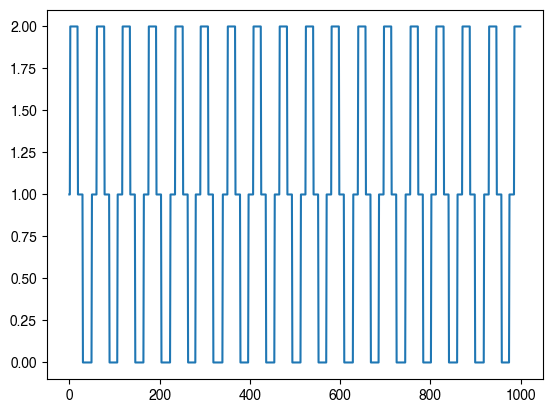

In [41]:
plt.plot(nhalf_release)

In [13]:
from matplotlib.colors import LinearSegmentedColormap

def power_law_colormap(cmap_name, gamma):
    # Get the existing colormap
    original_cmap = colormaps[cmap_name]
    
    # Create an array for the range [0, 1]
    t = np.linspace(0, 1, 1024)
    
    # Apply the power law transformation
    t_power = t ** gamma
    
    # Create the new colormap by interpolating the original colormap's colors
    new_cmap = LinearSegmentedColormap.from_list(f'{cmap_name}_power_{gamma}', original_cmap(t_power))
    
    return new_cmap

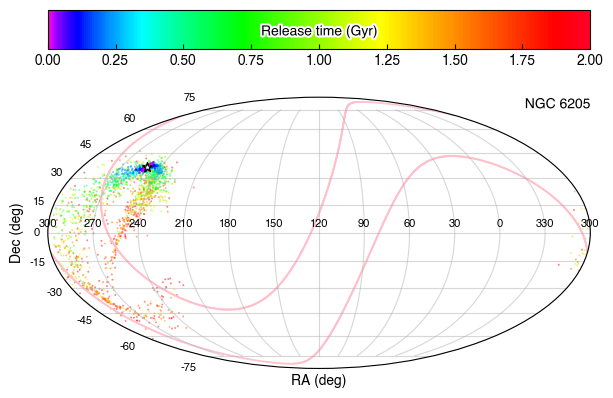

In [42]:
fig = plt.figure(figsize=(7, 1+4*len(gc_stream_list)))
gs = gridspec.GridSpec(len(gc_stream_list)+1, 1, height_ratios=[0.12] + [1] * len(gc_stream_list))
plt.subplots_adjust(hspace=0.12)
axs = [fig.add_subplot(gs[i+1], projection='mollweide') for i in range(len(gc_stream_list))]

# make color bar
cbar_ax = fig.add_subplot(gs[0])
cbar_ax.tick_params(direction='in')

# cmap = colormaps['gist_rainbow_r']
cmap = power_law_colormap('gist_rainbow_r', 0.5)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=0, vmax=t_tot.to_value('Gyr')))
# sm.set_array([])  # Dummy array for the colorbar

cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
# cbar.set_label('Release time (Gyr)', labelpad=10)
cbar.ax.xaxis.set_ticks_position('bottom')
cbar.ax.xaxis.set_label_position('bottom')

txt = cbar.ax.text(0.5, 0.45, r'Release time (Gyr)', transform=cbar.ax.transAxes, va='center', ha='center')
txt.set_path_effects([PathEffects.withStroke(linewidth=3, foreground='w')])


for key, ax0 in zip(gc_stream_list, axs):

    mockstream = mockstreams[key]
    
    cmap = power_law_colormap('gist_rainbow_r', 0.5)

    x = np.remainder(120-mockstream.ra, 360)
    x[x>180] -= 360
    x *= np.pi/180
    x_prog = np.remainder(120-mockstream.c_prog.ra.to_value('deg'), 360)
    x_prog -= 360 if x_prog>180 else 0
    x_prog *= np.pi/180
    
    y = mockstream.dec * np.pi/180
    y_prog = mockstream.c_prog.dec * np.pi/180
    
    ax0.scatter(x, y, s=2, alpha=0.5, c=-mockstream.release_time*0.978, ec='None', cmap=cmap, vmin=0, vmax=t_tot.to_value('Gyr'))
    ax0.scatter(x_prog, y_prog, s=50, marker='*', fc='w', ec='k', lw=1)

    txt = ax0.text(1, 1, r'%s'%key.replace('_', ' '), transform=ax0.transAxes, va='top', ha='right')
    txt.set_path_effects([PathEffects.withStroke(linewidth=3, foreground='w')])

    for nsample, bvalue in zip([1000,1000], [-20,20]):
        l = np.linspace(0,360,nsample)
        b = np.full_like(l, fill_value=bvalue)
        gp = coord.SkyCoord(l=l*u.deg, b=b*u.deg, frame='galactic').transform_to(coord.ICRS)
        x = np.remainder(120-gp.ra.to_value('deg'), 360)
        x[x>180] -= 360
        x *= np.pi/180
        y = gp.dec.to_value('deg') * np.pi/180
        ax0.scatter(x, y, fc='pink', ec='None', s=2)

    ax0.set_xlabel(r'RA (deg)')
    ax0.set_ylabel(r'Dec (deg)')
    ax0.grid(True, alpha=0.5)
    ax0.set_xticks(np.array([-180,-150,-120,-90,-60,-30,0,30,60,90,120,150,180])*np.pi/180,
        [r'300',r'270',r'240',r'210',r'180',r'150',r'120',r'90',r'60',r'30',r'0',r'330',r'300'], fontsize=8)
    ax0.set_yticks(np.array([-75,-60,-45,-30,-15,0,15,30,45,60,75])*np.pi/180,
        [r'-75',r'-60',r'-45',r'-30',r'-15',r'0',r'15',r'30',r'45',r'60',r'75'], fontsize=8)

## Make KDE

In [15]:
# from scipy.spatial.distance import pdist

def epanechnikov(u):
    k = 0.75*(1.-u**2)
    k[k<0] = 0
    return k
    
def gaussian(u):
    return 0.3989422804014327 * np.exp(-0.5*u**2)

def kde(Xdata, Xgrid, h, kernel=gaussian, proj_axes=[]):
    non_proj_axes = np.ones(Xdata.shape[1], dtype=bool)
    non_proj_axes[proj_axes] = False
    dist = np.sqrt(np.sum(((Xgrid[:,non_proj_axes]-Xdata[:,non_proj_axes][:,np.newaxis])/h[:,non_proj_axes][:,np.newaxis])**2, axis=2))
    k = np.sum(kernel(dist) / np.prod(h[:,non_proj_axes],axis=1)[:,np.newaxis], axis=0)
    # k_norm = np.sum(kernel(dist))
    return k/len(Xdata)

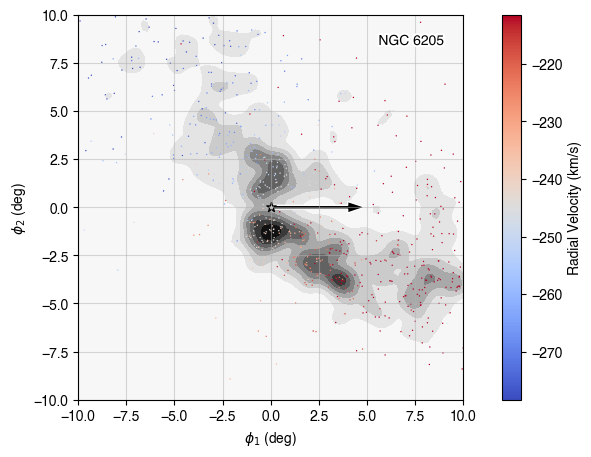

In [47]:
# in great circle frame

xlim = (-10, 10)
ylim = (-10, 10)

fig, ax0 = plt.subplots(1, 1, figsize=(10,5))

mockstream = mockstreams[key]

# cmap = power_law_colormap('gist_rainbow_r', 0.5)

x = mockstream.phi1
x_prog = mockstream.c_prog_GreatCircle.phi1.to_value('deg')

y = mockstream.phi2
y_prog = mockstream.c_prog_GreatCircle.phi2.to_value('deg')

mask_vr = (mockstream.release_time > -6)
mask_vr &= ((x > xlim[0]) & (x < xlim[1]) & (y > ylim[0]) & (y < ylim[1]))
# mask_vr &= ((mockstream.vr > -280) & (mockstream.vr < -200))
# mask_vr &= ((np.abs(mockstream.mu_ra--3.138) < 1) & (np.abs(mockstream.mu_dec--2.572) < 1))
# mask_vr &= ((np.abs(mockstream.mu_ra--3.138) < 1) & (np.abs(mockstream.mu_dec--2.572+mockstream.mu_ra--3.138) < 1))

# make KDE
x_data, y_data, vrad_data, mu_x, mu_y = (x[mask_vr], y[mask_vr], mockstream.vr[mask_vr], 
    mockstream.c_GreatCircle.pm_phi1_cosphi2.to_value('mas/yr')[mask_vr], mockstream.c_GreatCircle.pm_phi2.to_value('mas/yr')[mask_vr])
Xdata = np.c_[x_data, y_data, vrad_data, mu_x, mu_y]
# hdata = np.c_[np.full_like(x_data, fill_value=1), np.full_like(x_data, fill_value=1), np.full_like(x_data, fill_value=2), 
#     np.full_like(x_data, fill_value=0.01), np.full_like(x_data, fill_value=0.01)]
# n_neighbor = 4**5
# hdata = np.c_[get_h(x_data,n_neighbor),get_h(y_data,n_neighbor),get_h(vrad_data,n_neighbor),get_h(mu_ra,n_neighbor),get_h(mu_dec,n_neighbor)]
f_h = 0.1
hdata = np.c_[
    np.full_like(x_data, fill_value=np.max([0.01, f_h*np.std(x_data)])),
    np.full_like(x_data, fill_value=np.max([0.01, f_h*np.std(y_data)])),
    np.full_like(x_data, fill_value=np.max([1, f_h*np.std(vrad_data)])),
    np.full_like(x_data, fill_value=np.max([0.1, f_h*np.std(mu_x)])),
    np.full_like(x_data, fill_value=np.max([0.1, f_h*np.std(mu_y)]))
]
x_grid, y_grid, vrad_grid, mu_x_grid, mu_y_grid = np.meshgrid(np.arange(xlim[0],xlim[1]+0.1,0.2), np.arange(ylim[0],ylim[1]+0.1,0.2), [-244.5], [1.3], [0])
Xgrid = np.c_[x_grid.flatten(), y_grid.flatten(), vrad_grid.flatten(), mu_x_grid.flatten(), mu_y_grid.flatten()]
Ygrid = kde(Xdata, Xgrid, hdata, kernel=gaussian, proj_axes=[2,3,4])
Ygrid = Ygrid.reshape(x_grid.shape)

ax0.contourf(x_grid[:,:,0,0,0], y_grid[:,:,0,0,0], Ygrid[:,:,0,0,0], cmap='Greys')

# make scatter plot
vrlim = (mockstream.c_prog.radial_velocity.to_value('km/s')-1*np.std(mockstream.vr[mask_vr]),
         mockstream.c_prog.radial_velocity.to_value('km/s')+1*np.std(mockstream.vr[mask_vr]))
cs = ax0.scatter(x[mask_vr], y[mask_vr], s=1, alpha=1, c=mockstream.vr[mask_vr], ec='None', cmap='coolwarm', vmin=vrlim[0], vmax=vrlim[1])

vx = mockstream.c_prog_GreatCircle.pm_phi1_cosphi2.to_value('mas/yr')
vy = mockstream.c_prog_GreatCircle.pm_phi2.to_value('mas/yr')
norm = 0.2*(xlim[1]-xlim[0]) / np.sqrt(vx**2 + vy**2)
ax0.arrow(0,0,norm*vx,norm*vy, width=0.2, fc='k', ec='w')
ax0.scatter(x_prog, y_prog, s=50, marker='*', fc='w', ec='k', lw=1)


txt = ax0.text(0.95, 0.95, r'%s'%key.replace('_', ' '), transform=ax0.transAxes, va='top', ha='right')
txt.set_path_effects([PathEffects.withStroke(linewidth=3, foreground='w')])

cbar = fig.colorbar(cs)
cbar.ax.set_ylabel(r'Radial Velocity (km/s)')

ax0.set_xlabel(r'$\phi_1$ (deg)')
ax0.set_ylabel(r'$\phi_2$ (deg)')
ax0.set_xlim(xlim[0],xlim[1])
ax0.set_ylim(ylim[0],ylim[1])
ax0.grid(True, alpha=0.5)
ax0.set_aspect('equal')

plt.show()

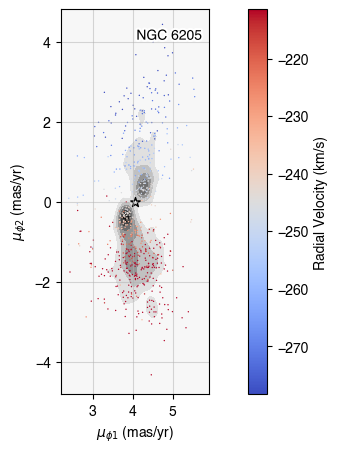

In [44]:
xlim = (mockstream.c_prog_GreatCircle.pm_phi1_cosphi2.to_value('mas/yr')-3*np.std(mu_x),
        mockstream.c_prog_GreatCircle.pm_phi1_cosphi2.to_value('mas/yr')+3*np.std(mu_x))
ylim = (-3*np.std(mu_y),+3*np.std(mu_y))

fig, ax0 = plt.subplots(1, 1, figsize=(10,5))

x_grid, y_grid, vrad_grid, mu_x_grid, mu_y_grid = np.meshgrid([0], [0], [-55], np.linspace(xlim[0],xlim[1],100+1), np.linspace(ylim[0],ylim[1],100+1))
Xgrid = np.c_[x_grid.flatten(), y_grid.flatten(), vrad_grid.flatten(), mu_x_grid.flatten(), mu_y_grid.flatten()]
Ygrid = kde(Xdata, Xgrid, hdata, kernel=gaussian, proj_axes=[0,1,2])
Ygrid = Ygrid.reshape(x_grid.shape)

ax0.contourf(mu_x_grid[0,0,0,:,:], mu_y_grid[0,0,0,:,:], Ygrid[0,0,0,:,:], cmap='Greys')

# make scatter plot

x = mu_x
x_prog = mockstream.c_prog_GreatCircle.pm_phi1_cosphi2.to_value('mas/yr')
y = mu_y
y_prog = mockstream.c_prog_GreatCircle.pm_phi2.to_value('mas/yr')

cs = ax0.scatter(x, y, s=1, alpha=1, c=mockstream.vr[mask_vr], ec='None', cmap='coolwarm', vmin=vrlim[0], vmax=vrlim[1])
ax0.scatter(x_prog, y_prog, s=50, marker='*', fc='w', ec='k', lw=1)

txt = ax0.text(0.95, 0.95, r'%s'%key.replace('_', ' '), transform=ax0.transAxes, va='top', ha='right')
txt.set_path_effects([PathEffects.withStroke(linewidth=3, foreground='w')])

cbar = fig.colorbar(cs)
cbar.ax.set_ylabel(r'Radial Velocity (km/s)')

ax0.set_xlabel(r'$\mu_{\phi1}$ (mas/yr)')
ax0.set_ylabel(r'$\mu_{\phi2}$ (mas/yr)')
ax0.set_xlim(xlim[0],xlim[1])
ax0.set_ylim(ylim[0],ylim[1])
ax0.grid(True, alpha=0.5)
ax0.set_aspect('equal')

plt.show()

## DESI

In [22]:
import numpy as np
import scipy.stats
from scipy.interpolate import RegularGridInterpolator

import astropy.table as atpy
import astropy.coordinates as coord
import astropy.io.fits as pyfits
import astropy.units as u
import gala.coordinates as gc
from gala.coordinates import GreatCircleICRSFrame

In [23]:
# load GC
cl_c = coord.SkyCoord.from_name(key.replace('_', ' '))
angle_tid = np.rad2deg(1e-3*gc_list.loc[key].rt / gc_list.loc[key].R_Sun)

In [24]:
# Load DESI DR1 MWS

RV_T = atpy.Table().read('/Users/ybchen/Downloads/mwsall-pix-iron.fits',
                         'RVTAB',
                         mask_invalid=False)
G_T = atpy.Table().read('/Users/ybchen/Downloads/mwsall-pix-iron.fits',
                         'GAIA',
                         mask_invalid=False)

In [25]:
main_sel = RV_T['PRIMARY'] & (RV_T['RVS_WARN'] == 0) & (RV_T['RR_SPECTYPE'] == 'STAR')
main_sel &= ((~np.isnan(RV_T['TARGET_RA'])) & (~np.isnan(RV_T['TARGET_DEC'])) & (~np.isnan(RV_T['VRAD'])) & (~np.isnan(G_T['PMRA'])) & (~np.isnan(G_T['PMDEC'])))

In [26]:
# RA-Dec selection

# xlim = (-120, -100)
# ylim = (30, 40)

# mask = main_sel & (RV_T['TARGET_RA']>xlim[0]+360) & (RV_T['TARGET_RA']<xlim[1]+360) & (RV_T['TARGET_DEC']>ylim[0]) & (RV_T['TARGET_DEC']<ylim[1])
# mask &= ((np.abs(RV_T['TARGET_RA']-cl_c.ra.degree)>1) | (np.abs(RV_T['TARGET_DEC']-cl_c.dec.degree)>1))
# mask &= ((~np.isnan(RV_T['TARGET_RA'])) & (~np.isnan(RV_T['TARGET_DEC'])) & (~np.isnan(RV_T['VRAD'])) & (~np.isnan(G_T['PMRA'])) & (~np.isnan(G_T['PMDEC'])))
# mask &= ((RV_T['ALPHAFE']>-0.399) & (RV_T['ALPHAFE']<1.119) & (~np.isnan(RV_T['FEH'])))

In [27]:
# ra_desi, dec_desi, vr_desi, mu_ra_desi, mu_dec_desi = RV_T['TARGET_RA'][mask], RV_T['TARGET_DEC'][mask], RV_T['VRAD'][mask], G_T['PMRA'][mask], G_T['PMDEC'][mask]
# ra_desi[ra_desi>180] -= 360
# feh_desi, alphafe_desi = RV_T['FEH'][mask], RV_T['ALPHAFE'][mask]

In [28]:
# Great circle selection

c_desi_all = coord.SkyCoord(RV_T['TARGET_RA']*u.deg, RV_T['TARGET_DEC']*u.deg,
    pm_ra_cosdec=G_T['PMRA']*u.mas/u.yr, pm_dec=G_T['PMDEC']*u.mas/u.yr, frame='icrs')

frame = GreatCircleICRSFrame.from_R(mockstreams[key].mat)
c_GreatCircle_desi_all = c_desi_all.transform_to(frame)

phi1_desi_all, phi2_desi_all, pm_phi1_cosphi2_desi_all, pm_phi2_desi_all = (
    c_GreatCircle_desi_all.phi1.to_value('deg'), c_GreatCircle_desi_all.phi2.to_value('deg'),
    c_GreatCircle_desi_all.pm_phi1_cosphi2.to_value('mas/yr'), c_GreatCircle_desi_all.pm_phi2.to_value('mas/yr'),
)

        Use @ instead. [gala.coordinates.greatcircle]
        Use @ instead.


In [29]:
xlim = (-10, 10)
ylim = (-10, 10)

mask = main_sel & (phi1_desi_all>xlim[0]) & (phi1_desi_all<xlim[1]) & (phi2_desi_all>ylim[0]) & (phi2_desi_all<ylim[1])
# mask &= ((np.abs(phi1_desi_all)>0.5) | (np.abs(phi2_desi_all)>0.5))
mask &= (phi1_desi_all**2 + phi2_desi_all**2 > angle_tid**2)
mask &= ((RV_T['ALPHAFE']>-0.399) & (RV_T['ALPHAFE']<1.119) & (~np.isnan(RV_T['FEH'])))

In [30]:
ra_desi, dec_desi, vr_desi, mu_ra_desi, mu_dec_desi = phi1_desi_all[mask], phi2_desi_all[mask], RV_T['VRAD'][mask], pm_phi1_cosphi2_desi_all[mask], pm_phi2_desi_all[mask]
feh_desi, alphafe_desi = RV_T['FEH'][mask], RV_T['ALPHAFE'][mask]

In [31]:
# get the bg distribution

# vr
vr_grid = np.arange(-600,600,1)
vr_prob = kde(vr_desi[:,np.newaxis], vr_grid[:,np.newaxis], 10*np.ones_like(vr_desi)[:,np.newaxis], kernel=gaussian)

# mu_ra
mu_ra_grid = np.arange(-50,50,1)
mu_ra_prob = kde(mu_ra_desi[:,np.newaxis], mu_ra_grid[:,np.newaxis], 1*np.ones_like(vr_desi)[:,np.newaxis], kernel=gaussian)

# mu_dec
mu_dec_grid = np.arange(-50,50,1)
mu_dec_prob = kde(mu_dec_desi[:,np.newaxis], mu_dec_grid[:,np.newaxis], 1*np.ones_like(vr_desi)[:,np.newaxis], kernel=gaussian)

# feh vs alpha
metal_desi = np.c_[feh_desi, alphafe_desi]
feh_list, alphafe_list = np.arange(-4,1.001,0.1), np.arange(-0.4,1.201,0.1)
feh_grid, alphafe_grid = np.meshgrid(feh_list, alphafe_list)
metal_grid = np.c_[feh_grid.flatten(), alphafe_grid.flatten(),]
metal_prob = kde(metal_desi, metal_grid, 0.1*np.ones_like(metal_desi), kernel=gaussian)
metal_prob = metal_prob.reshape(feh_grid.shape)
metal_interp = RegularGridInterpolator((feh_list, alphafe_list), metal_prob.T)

In [32]:
# get the stream distribution
# RA-Dec selection

# feh vs alpha from the GC

# mask_gc = main_sel & (RV_T['TARGET_RA']>xlim[0]+360) & (RV_T['TARGET_RA']<xlim[1]+360) & (RV_T['TARGET_DEC']>ylim[0]) & (RV_T['TARGET_DEC']<ylim[1])
# mask_gc &= ((np.abs(RV_T['TARGET_RA']-cl_c.ra.degree)<0.2) & (np.abs(RV_T['TARGET_DEC']-cl_c.dec.degree)<0.2))
# mask_gc &= ((~np.isnan(RV_T['TARGET_RA'])) & (~np.isnan(RV_T['TARGET_DEC'])) & (~np.isnan(RV_T['VRAD'])) & (~np.isnan(G_T['PMRA'])) & (~np.isnan(G_T['PMDEC'])))
# mask_gc &= ((RV_T['ALPHAFE']>-0.399) & (RV_T['ALPHAFE']<1.119) & (~np.isnan(RV_T['FEH'])))

# feh_gc_desi, alphafe_gc_desi = RV_T['FEH'][mask_gc], RV_T['ALPHAFE'][mask_gc]

# metal_gc_desi = np.c_[feh_gc_desi, alphafe_gc_desi]
# metal_gc_prob = kde(metal_gc_desi, metal_grid, 0.1*np.ones_like(metal_gc_desi), kernel=gaussian)
# metal_gc_prob = metal_gc_prob.reshape(feh_grid.shape)
# metal_gc_interp = RegularGridInterpolator((feh_list, alphafe_list), metal_gc_prob.T)

In [33]:
# get the stream distribution
# Great circle selection

# feh vs alpha from the GC

mask_gc = main_sel & (phi1_desi_all>xlim[0]) & (phi1_desi_all<xlim[1]) & (phi2_desi_all>ylim[0]) & (phi2_desi_all<ylim[1])
# mask_gc &= ((np.abs(phi1_desi_all)<0.1) & (np.abs(phi2_desi_all)<0.1))
mask_gc &= (phi1_desi_all**2 + phi2_desi_all**2 < (0.3*angle_tid)**2)
mask_gc &= ((RV_T['ALPHAFE']>-0.399) & (RV_T['ALPHAFE']<1.119) & (~np.isnan(RV_T['FEH'])))

feh_gc_desi, alphafe_gc_desi = RV_T['FEH'][mask_gc], RV_T['ALPHAFE'][mask_gc]

metal_gc_desi = np.c_[feh_gc_desi, alphafe_gc_desi]
metal_gc_prob = kde(metal_gc_desi, metal_grid, 0.1*np.ones_like(metal_gc_desi), kernel=gaussian)
metal_gc_prob = metal_gc_prob.reshape(feh_grid.shape)
metal_gc_interp = RegularGridInterpolator((feh_list, alphafe_list), metal_gc_prob.T)

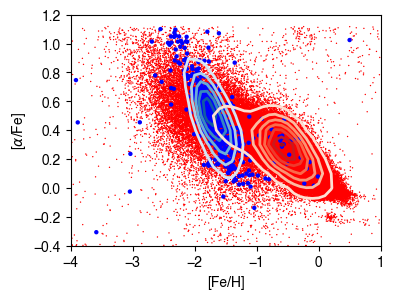

In [34]:

fig, ax0 = plt.subplots(1, 1, figsize=(4,3))

plt.scatter(feh_desi, alphafe_desi, s=1, ec='none', fc='r', label='GC')
plt.scatter(feh_gc_desi, alphafe_gc_desi, s=10, ec='none', fc='b', label='BG')

plt.contour(feh_grid, alphafe_grid, metal_gc_prob, cmap='Blues', linewidths=2)
plt.contour(feh_grid, alphafe_grid, metal_prob, cmap='Reds', linewidths=2)

ax0.set_xlabel(r'[Fe/H]')
ax0.set_ylabel(r'[$\alpha$/Fe]')
ax0.set_xlim(-4, 1)
ax0.set_ylim(-0.4, 1.2)
# ax0.grid(True, alpha=0.5)

plt.show()

### compute likelihood

In [45]:
# compute probabilities

prob_bg = \
    1 / (xlim[1]-xlim[0]) * \
    1 / (ylim[1]-ylim[0]) * \
    np.interp(vr_desi, vr_grid, vr_prob) * \
    np.interp(mu_ra_desi, mu_ra_grid, mu_ra_prob) * \
    np.interp(mu_dec_desi, mu_dec_grid, mu_dec_prob) * \
    metal_interp(metal_desi)

Xdesi = np.c_[ra_desi, dec_desi, vr_desi, mu_ra_desi, mu_dec_desi]
prob_stream = \
    kde(Xdata, Xdesi, hdata, kernel=gaussian) * \
    metal_gc_interp(metal_desi)

$$
\ln L = \sum_i \ln[f_{\rm s}P_{{\rm s},i}+(1-f_{\rm s})P_{{\rm bg},i}]
$$

$$
P_{\rm s} = P(\alpha, \delta, \mu_\alpha, \mu_\delta, v_r)P({\rm [Fe/H], [\alpha/Fe]})
$$

$$
P_{\rm bg} = P(\alpha)P(\delta)P(\mu_\alpha)P(\mu_\delta)P(v_r)P({\rm [Fe/H], [\alpha/Fe]})
$$

peak at 8.71e-04


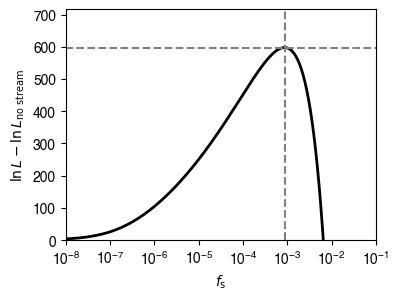

In [46]:
# compute likelihood

frac_list = 10.**np.arange(-10,-0.5,0.02)
# frac_list = np.arange(0.0,0.1,0.001)
lnL_list = []

lnL_base = np.sum(np.log(prob_bg))

for frac in frac_list:
    lnL_list.append(np.sum(np.log(prob_stream*frac + prob_bg*(1-frac))))

lnL_list = np.array(lnL_list)

fig, ax0 = plt.subplots(1, 1, figsize=(4,3))

ax0.plot(frac_list, lnL_list-lnL_base, c='k', lw=2)
ax0.hlines(np.max(lnL_list)-lnL_base, 1e-10, 1e0, color='gray', ls='--')
ax0.vlines(frac_list[np.argmax(lnL_list)], 0, 2000, color='gray', ls='--')

print('peak at %.2e'%frac_list[np.argmax(lnL_list)])

ax0.set_xscale('log')
# ax0.set_xscale('log')
ax0.set_xlabel(r'$f_{\rm s}$')
ax0.set_ylabel(r'$\ln L-\ln L_{\rm no\ stream}$')
ax0.set_xlim(1e-8, 1e-1)
ax0.set_ylim(0, 1.2*(np.max(lnL_list)-lnL_base))
ax0.set_xticks(10**np.arange(-8,-1+0.1,1))
# ax0.grid(True, alpha=0.5)

plt.show()

number of stream stars: 140, number of all stars: 159727


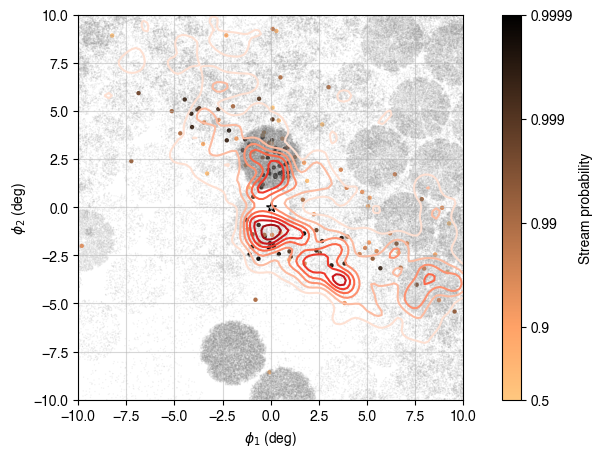

In [48]:

fig, ax0 = plt.subplots(1, 1, figsize=(10,5))

frac = frac_list[np.argmax(lnL_list)]

prob = frac*prob_stream / (frac*prob_stream + (1-frac)*prob_bg)

mask_select = prob > 0.5

print('number of stream stars: %d, number of all stars: %d'%(len(ra_desi[mask_select]),len(ra_desi)))

ax0.contour(x_grid[:,:,0,0,0], y_grid[:,:,0,0,0], Ygrid[:,:,0,0,0], cmap='Reds')

# cs = ax0.scatter(ra_desi[mask_select], dec_desi[mask_select], c=vr_desi[mask_select], ec='None', cmap='coolwarm', vmin=vrlim[0], vmax=vrlim[1], s=10)
# cbar = fig.colorbar(cs)
# cbar.ax.set_ylabel(r'Radial velocity (km/s)')

cs = ax0.scatter(ra_desi[mask_select], dec_desi[mask_select], c=np.log10(1-prob[mask_select]), ec='None', cmap='copper', vmin=-4, vmax=np.log10(0.5), s=10)
cbar = fig.colorbar(cs, ticks=[-4,-3,-2,-1,np.log10(0.5)])
cbar.ax.set_yticklabels(['0.9999', '0.999', '0.99', '0.9', '0.5'])
cbar.ax.set_ylabel(r'Stream probability')
cbar.ax.set_ylim(np.log10(0.5),-4)

# ax0.scatter(x_prog, y_prog, s=50, marker='*', fc='w', ec='k', lw=1)
ax0.scatter(0, 0, s=50, marker='*', fc='w', ec='k', lw=1)
ax0.scatter(ra_desi, dec_desi, fc='gray', ec='None', s=1, alpha=0.1, zorder=1)

ax0.set_xlabel(r'$\phi_1$ (deg)')
ax0.set_ylabel(r'$\phi_2$ (deg)')
ax0.set_xlim(xlim[0], xlim[1])
ax0.set_ylim(ylim[0], ylim[1])
ax0.set_ylim(-10, 10)
ax0.grid(True, alpha=0.5)
ax0.set_aspect('equal')

plt.show()

## Hey, it's the last line! Stop pressing `Shift + Enter`